#CUSTOMER SEGMENTATION

#INTRODUCTION

Customer segmentation is an important analytical technique used by businesses to understand and categorize their customers based on similar characteristics and behaviors. Instead of treating all customers the same, segmentation helps in identifying distinct groups such as high spenders, budget shoppers, loyal customers, or occasional buyers. By understanding these groups, companies can design better marketing strategies, improve customer satisfaction, and increase overall profitability.

In this project, we use K-Means Clustering, an unsupervised machine learning algorithm, to perform customer segmentation. The K-Means algorithm groups customers into clusters based on how similar they are in terms of features like Age, Annual Income, and Spending Score. These features reflect customers’ purchasing behaviour and help in identifying meaningful patterns.

The dataset used in this analysis contains customer demographic and spending-related information. By applying data preprocessing, scaling, and clustering techniques, we aim to discover distinct customer profiles. These insights can help businesses create targeted marketing campaigns, personalized offers, and better customer experience strategies.

#PROBLEM STATEMENT

Goal:

1.Identify distinct customer groups based on their demographics and purchasing behavior.

2.Understand customer patterns such as spending habits, income levels, and age groups.

3.Enable targeted marketing strategies by categorizing customers into meaningful segments.

4.Improve customer retention and satisfaction through personalized offers and communication.

5.Enhance business decision-making by providing data-driven insights into customer behavior.

6.Support revenue growth by identifying high-value customers and optimizing marketing spend.

Objective:

1.Preprocess and scale numerical features to ensure fair contribution to clustering.

2.Determine the optimal number of clusters using methods like the Elbow method and Silhouette score.

3.Apply K-Means clustering to segment customers into meaningful groups.

4.Reduce dimensionality with PCA and visually interpret customer clusters.

5.Generate descriptive profiles for each cluster, summarizing key characteristics (age, income, spending score, gender mix).

6.Provide actionable marketing strategies tailored to each customer segment.

7.Support data-driven decision-making by identifying customer patterns and behavior trends.

Expected outcome:

1.Well-defined customer clusters created using K-Means, each representing a distinct behavioral group.

2.Visual representation of clusters using PCA scatter plots for easy interpretation.

3.Cluster profiles summarizing average age, income, spending score, and gender distribution for each segment.

4.Identification of high-value, low-value, and opportunity segments, enabling targeted decision-making.

5.Actionable marketing strategies tailored to each customer group based on their behavior and spending patterns.

6.Improved understanding of customer purchasing behavior, helping with product positioning and offer personalization.

7.Data-driven segmentation model that can be reused to classify new customers in the future.

8.Enhanced ability to optimize marketing budgets, resulting in better ROI and customer retention.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

#DATA UNDERSTANDING

In [ ]:
df=pd.read_csv("/content/Customer_Data.csv", sep=',')

In [ ]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.sample()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8438,C18666,5484.339435,1.0,0.0,0.0,0.0,5990.590134,0.0,0.0,0.0,0.25,14,0,6000.0,1229.434538,2453.164396,0.0,12


In [ ]:
df.shape

(8950, 18)

In [ ]:
df.columns.tolist()

['CUST_ID',
 'BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

#DATA CLEANING

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
df.dropna()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.rename(columns={"PURCHASES":"SHOPPING"},inplace=True)
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,SHOPPING,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [ ]:
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
SHOPPING,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


#DESCRIPTIVE STATISTICS

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,SHOPPING,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
print(df['SHOPPING'].value_counts())

SHOPPING
0.00       2044
45.65        27
150.00       16
60.00        16
100.00       13
           ... 
356.32        1
558.08        1
50.85         1
1053.52       1
1401.54       1
Name: count, Length: 6203, dtype: int64


#DATA VISUALIZATION

<Axes: xlabel='PAYMENTS', ylabel='Count'>

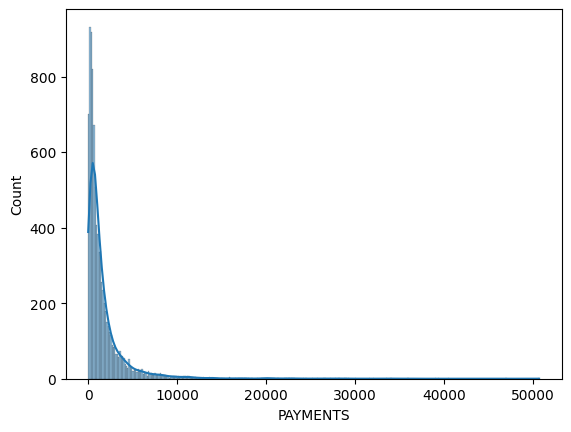

In [ ]:
sns.histplot(df['PAYMENTS'],kde=True)

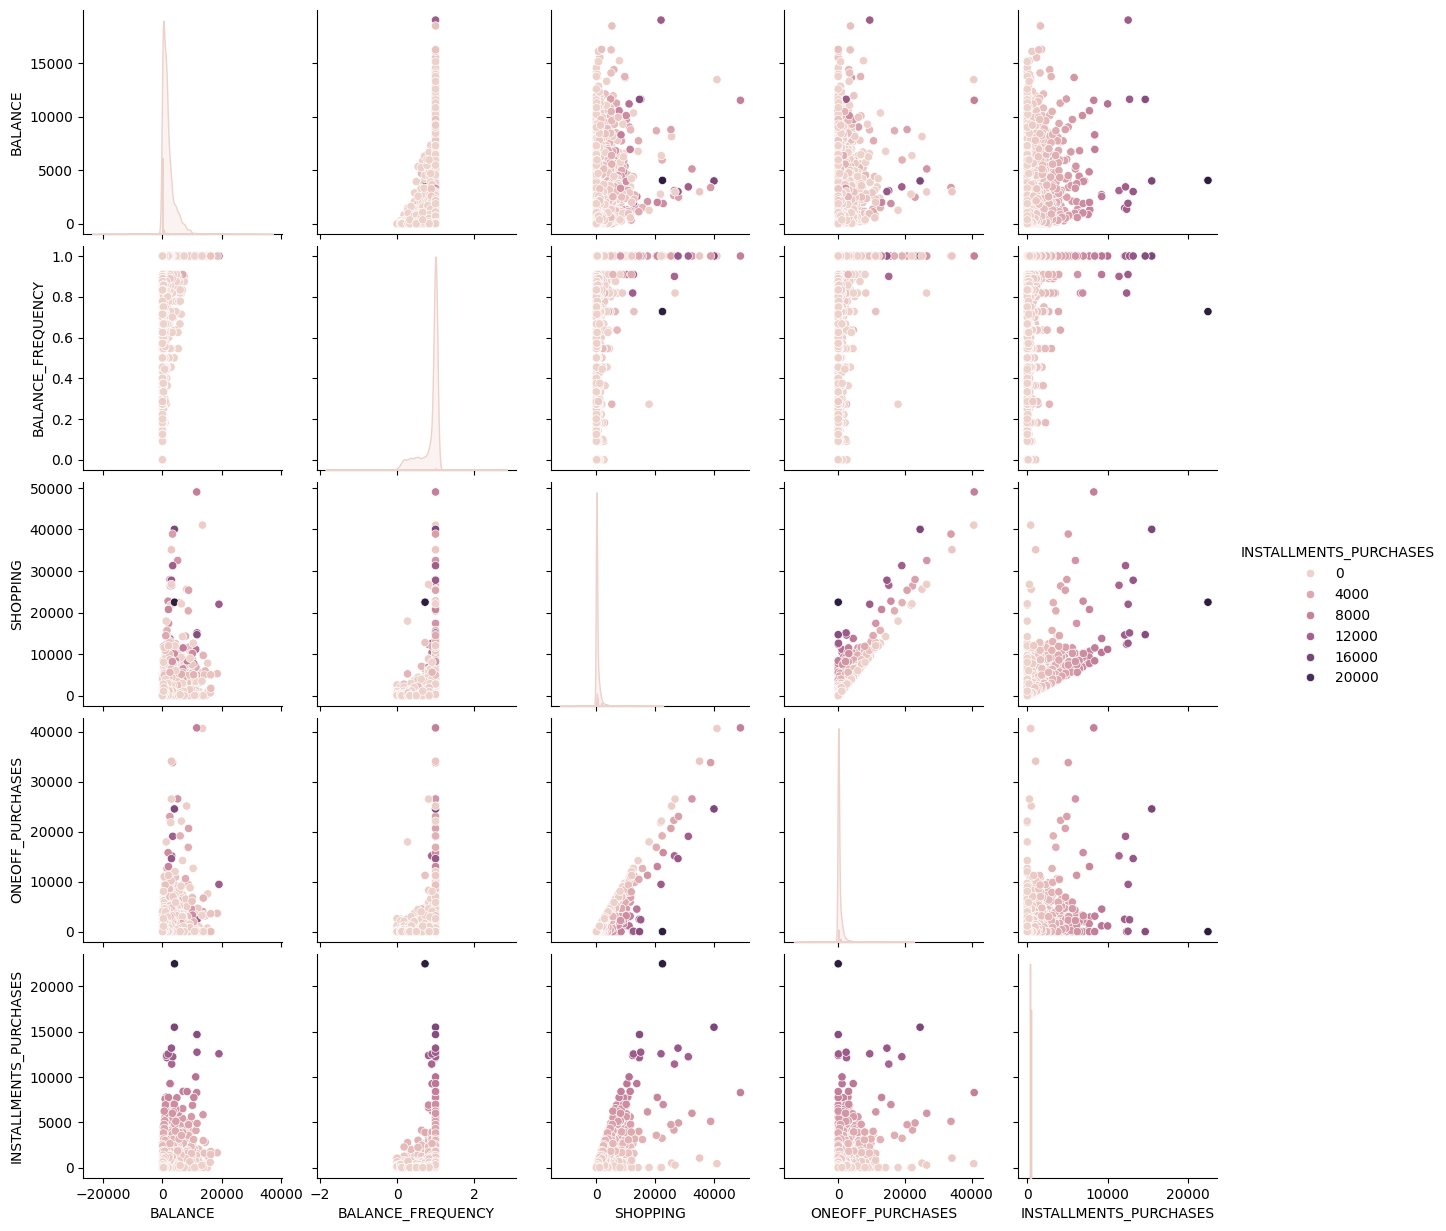

In [ ]:
sns.pairplot(data=df, vars=[
 'BALANCE',
 'BALANCE_FREQUENCY',
 'SHOPPING',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',],hue='INSTALLMENTS_PURCHASES')
plt.show()

#FEATURE ENGINEERING




In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns#Identify Categorical Columns
print("Categorical Columns:", cat_cols.tolist())

le_dict = {}  #Create a dictionary to store the encoders

for col in cat_cols:#Loop and Encode Each Categorical Column
    le = LabelEncoder()#Create encoder
    df[col] = le.fit_transform(df[col])#Fit & Transform
    le_dict[col] = le#Save Encoder
    print(f"Encoded: {col}")#Print column name


Categorical Columns: ['CUST_ID']
Encoded: CUST_ID


In [ ]:
a=df.select_dtypes(include='bool').columns#Select Boolean Columns
#This finds all columns in your dataframe that have True/False values.
for col in a:
  df[col] = df[col].astype('int64')##Convert Boolean → Integer
print('completed')
df.info()

completed
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   int64  
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   SHOPPING                          8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 

#CORRELATION ANALYSIS

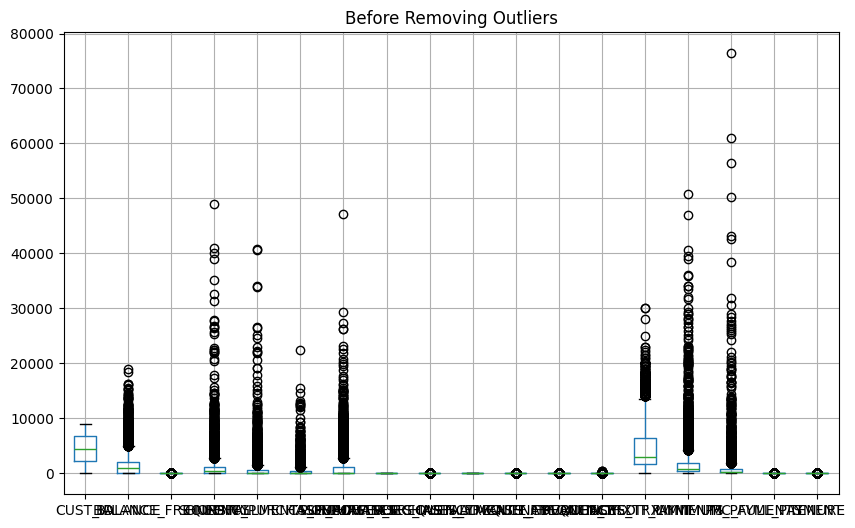

In [ ]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.title("Before Removing Outliers")
plt.show()

Removed 5956 rows with outliers.


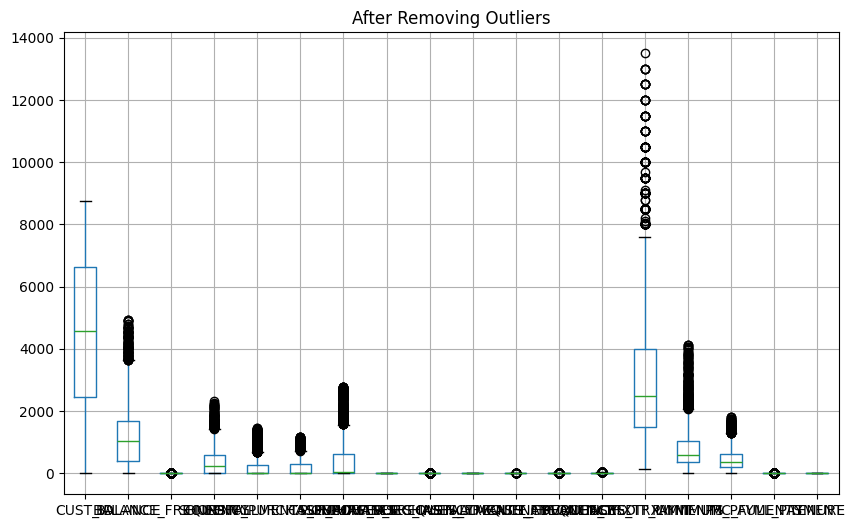

In [ ]:
numeric_cols = df.select_dtypes(include=['number'])#Select only numeric columns
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
#Calculate Q1 & Q3
IQR = Q3 - Q1
#Calculate IQR (Interquartile Range)
outlier_condition = ((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)
#Create condition to detect outliers
df_clean = df[~outlier_condition]
#Remove outlier rows
print(f"Removed {df.shape[0] - df_clean.shape[0]} rows with outliers.")
#Print number of removed rows
numeric_cols_clean = df_clean.select_dtypes(include=['number'])
#Get numeric columns of cleaned dataset
plt.figure(figsize=(10,6))#Plot boxplot after removing outliers
numeric_cols_clean.boxplot()
plt.title("After Removing Outliers")
plt.show()

In [ ]:
df.corr(numeric_only=True)['SHOPPING'].sort_values(ascending=False)

,SHOPPING
SHOPPING,1.000000
ONEOFF_PURCHASES,0.916845
PURCHASES_TRX,0.689561
INSTALLMENTS_PURCHASES,0.679896
PAYMENTS,0.603264
ONEOFF_PURCHASES_FREQUENCY,0.498430
PURCHASES_FREQUENCY,0.393017
CREDIT_LIMIT,0.356963
PURCHASES_INSTALLMENTS_FREQUENCY,0.315567
BALANCE,0.181261


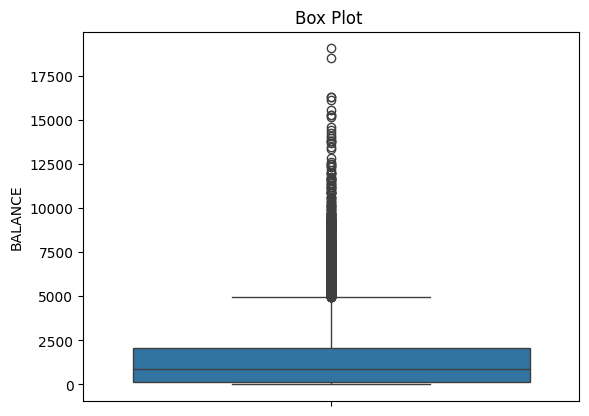

In [ ]:
sns.boxplot(y='BALANCE', data=df)
plt.title('Box Plot ')
plt.show()

In [ ]:
from scipy import stats
for i in df.select_dtypes(include=np.number).columns:#elect numeric columns
   z_scores = np.abs(stats.zscore(df[i]))#Loop through each numeric column
   outliers = df[z_scores > 3]#Identify rows where Z-score > 3
   print(f'Number of outliers in {i}: {outliers.shape[0]}')

Number of outliers in CUST_ID: 0
Number of outliers in BALANCE: 196
Number of outliers in BALANCE_FREQUENCY: 176
Number of outliers in SHOPPING: 135
Number of outliers in ONEOFF_PURCHASES: 122
Number of outliers in INSTALLMENTS_PURCHASES: 137
Number of outliers in CASH_ADVANCE: 182
Number of outliers in PURCHASES_FREQUENCY: 0
Number of outliers in ONEOFF_PURCHASES_FREQUENCY: 0
Number of outliers in PURCHASES_INSTALLMENTS_FREQUENCY: 0
Number of outliers in CASH_ADVANCE_FREQUENCY: 199
Number of outliers in CASH_ADVANCE_TRX: 172
Number of outliers in PURCHASES_TRX: 185
Number of outliers in CREDIT_LIMIT: 0
Number of outliers in PAYMENTS: 159
Number of outliers in MINIMUM_PAYMENTS: 0
Number of outliers in PRC_FULL_PAYMENT: 0
Number of outliers in TENURE: 394


#FEATURE SCALING

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])#Selecting only numeric columns
from sklearn.preprocessing import StandardScaler#Importing StandardScaler

scaler = StandardScaler()#Applying StandardScaler
scaled_data = scaler.fit_transform(numeric_df)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)#Creating scaled dataframe
#Returns a DataFrame with the same columns but transformed values.


#FIND OPTIMAL K USING ELBOW METHOD

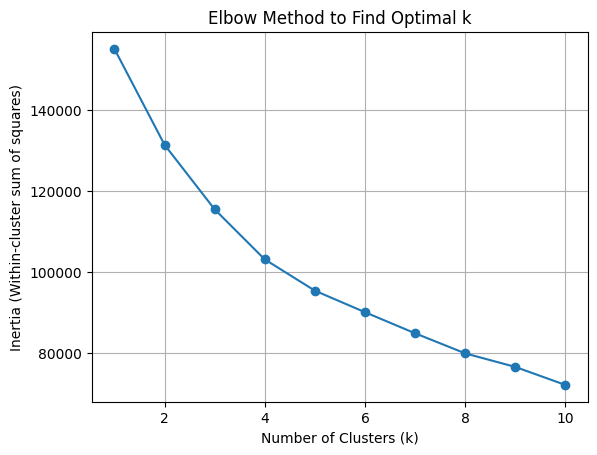

In [ ]:
inertia_values = []#Create Empty Lists
k_values = range(1, 11)#k_values = trying number of clusters from 1 to 10
#inertia_values = will store the inertia (error) for each k

scaled_df_cleaned = scaled_df.dropna() #Remove Missing Values

for k in k_values:#Loop Through Different Values of k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)#Creates a KMeans model for each value of k (number of clusters).
    kmeans.fit(scaled_df_cleaned) #Trains the KMeans algorithm on your scaled data.
    inertia_values.append(kmeans.inertia_)#This gives the within-cluster sum of squared distances
#→ smaller inertia = better clustering
#→ but after some point, improvement slows.

plt.plot(k_values, inertia_values, marker='o')#Plotting the Elbow Curve
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster sum of squares)")
plt.title("Elbow Method to Find Optimal k")
plt.grid(True)
plt.show()

#TRAIN K-MEANS MODEL

In [ ]:
k = 5 #Set number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)#Create K-Means model
labels = kmeans.fit_predict(scaled_df_cleaned)#Train model + get cluster labels

df_clustered = df.loc[scaled_df_cleaned.index].copy()#Match the cluster labels to original dataframe
df_clustered['Cluster'] = labels

print("K-means training complete!")
print(df_clustered.head())

K-means training complete!
   CUST_ID      BALANCE  BALANCE_FREQUENCY  SHOPPING  ONEOFF_PURCHASES  \
0        0    40.900749           0.818182     95.40              0.00   
1        1  3202.467416           0.909091      0.00              0.00   
2        2  2495.148862           1.000000    773.17            773.17   
4        4   817.714335           1.000000     16.00             16.00   
5        5  1809.828751           1.000000   1333.28              0.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                   95.40      0.000000             0.166667   
1                    0.00   6442.945483             0.000000   
2                    0.00      0.000000             1.000000   
4                    0.00      0.000000             0.083333   
5                 1333.28      0.000000             0.666667   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1        

#PCA VISUALIZATION

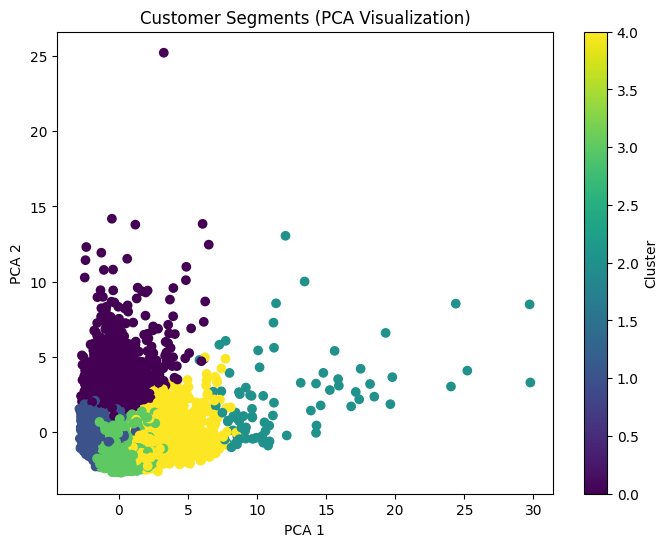

In [ ]:
pca = PCA(n_components=2)#Apply PCA to reduce dimensions
pca_data = pca.fit_transform(scaled_df_cleaned)

plt.figure(figsize=(8, 6))#Plot the PCA-transformed data
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap="viridis")
plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

#CREATE CLUSTER PROFILE

In [ ]:

numeric_columns_for_profiling = [col for col in numeric_df.columns if col in df_clustered.columns]
#Select numeric columns that exist in the clustered dataframe
cluster_profile = df_clustered.groupby("Cluster")[numeric_columns_for_profiling].mean()
#Group the data by Cluster
print("\nCluster Profiles:\n")
#Print the final cluster profile
print(cluster_profile)


Cluster Profiles:

             CUST_ID      BALANCE  BALANCE_FREQUENCY      SHOPPING  \
Cluster                                                              
0        3801.342402  4753.959500           0.967726    515.873452   
1        4596.013600  1140.194822           0.832300    278.636960   
2        2589.176471  4516.369799           0.976364  15897.090235   
3        5323.319468   620.938399           0.910087    789.140450   
4        3379.421240  1890.810395           0.977540   2900.434098   

         ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
Cluster                                                           
0              315.017833              200.950994   4793.477258   
1              226.526597               52.260864    658.816523   
2            10780.888000             5116.202235   1039.836264   
3              159.596226              630.153392    183.397743   
4             1960.150527              940.711226    348.696706   

         PURCHASES_

#GIVE MARKETING SUGGESTIONS FOR EACH CLUSTER

In [ ]:
for cluster in cluster_profile.index:#Loop through each cluster in the cluster profile
    print(f"\nCluster {cluster} Suggestions:")#Based on the cluster number, print suggestions

    if cluster == 0:
        print("• High balance and high credit limit, but low purchase activity. May be convenience users or those with emergency funds.")
        print("• Offer balance transfer promotions, credit limit increases, and premium services to enhance engagement.")
    elif cluster == 1:
        print("• Customers with moderate balance and frequent installment purchases. Likely value-conscious and budget-oriented.")
        print("• Promote installment payment plans, loyalty programs, and personalized offers on installment-eligible products.")
    elif cluster == 2:
        print("• Very high spending customers, especially one-off purchases, with high balances and payments. These are big spenders.")
        print("• Provide exclusive deals, VIP rewards, premium card upgrades, and early access to sales events.")
    elif cluster == 3:
        print("• Customers with moderate to high overall purchases, frequent usage, and good credit behavior (high full payment %). Often active shoppers.")
        print("• Focus on rewards programs, personalized product recommendations, and special discounts for frequent shoppers.")
    elif cluster == 4:
        print("• High cash advance usage, high balances, and low percentage of full payments. Potentially facing financial strain.")
        print("• Offer financial literacy resources, debt consolidation options, or tailored payment assistance programs.")


Cluster 0 Suggestions:
• High balance and high credit limit, but low purchase activity. May be convenience users or those with emergency funds.
• Offer balance transfer promotions, credit limit increases, and premium services to enhance engagement.

Cluster 1 Suggestions:
• Customers with moderate balance and frequent installment purchases. Likely value-conscious and budget-oriented.
• Promote installment payment plans, loyalty programs, and personalized offers on installment-eligible products.

Cluster 2 Suggestions:
• Very high spending customers, especially one-off purchases, with high balances and payments. These are big spenders.
• Provide exclusive deals, VIP rewards, premium card upgrades, and early access to sales events.



#DOCUMENTATION

The Customer_Data.csv dataset contains information about different customers. It is mainly used to understand customer behavior and group them into clusters using techniques like K-Means. This dataset helps businesses study how customers differ in their age, income, spending habits, and other personal details.

Each row represents one customer, and each column provides specific information about that customer. The dataset usually includes details such as CustomerID, Gender, Age, Annual Income, Spending Score, and sometimes other attributes like Profession, City, Work Experience, or Family Size. These details help analysts understand how customers behave and what type of products or services they may prefer.

The main purpose of this dataset is to perform customer segmentation. By analyzing the data, we can find groups of customers who behave similarly. For example, some customers may have high income and spend a lot, while others may have low income and spend very little. Identifying such groups helps businesses design better marketing strategies for each type of customer.

This dataset is very helpful for tasks like data exploration, feature scaling, applying clustering algorithms, and visualizing customer groups using PCA. It is simple, easy to work with, and a good choice for beginners learning machine learning and customer analytics.

Using this dataset, a business can answer important questions like which customers spend more, which customers may be interested in premium products, and which customers respond better to discounts. After clustering, each group of customers can be studied to understand their characteristics and create marketing strategies that match their behavior.

